# Weighted EfficientNet-B3 for Retinal OCT Disease Classification

This notebook implements an EfficientNet-B3 model with class weighting for multiclass classification of retinal OCT images from the Kermany2018 dataset.

EfficientNet-B3 is selected because of its compound scaling strategy, which balances network depth, width, and resolution. Since the dataset is imbalanced, class weights are computed from the training distribution and applied during training to reduce bias toward majority classes.

The model is evaluated using accuracy, precision, recall, F1-score, Macro F1-score, confusion matrix analysis, training time, and number of parameters.

In [1]:
import os
import time
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

from sklearn.utils.class_weight import compute_class_weight

import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, CSVLogger
from tensorflow.keras.applications import EfficientNetB3
from tensorflow.keras.applications.efficientnet import preprocess_input

print("TensorFlow version:", tf.__version__)
print("GPUs disponibles:", tf.config.list_physical_devices("GPU"))

2026-06-07 15:08:19.774143: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1780844899.797279     115 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1780844899.805309     115 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1780844899.824411     115 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780844899.824429     115 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780844899.824431     115 computation_placer.cc:177] computation placer alr

TensorFlow version: 2.19.0
GPUs disponibles: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


In [2]:
DATA_DIR = "/kaggle/input/datasets/fabrizioravelli/retinal-oct-images-splitted"

train_dir = os.path.join(DATA_DIR, "training", "train")
val_dir = os.path.join(DATA_DIR, "training", "val")
test_dir = os.path.join(DATA_DIR, "test")

print("Train existe:", os.path.exists(train_dir))
print("Val existe:", os.path.exists(val_dir))
print("Test existe:", os.path.exists(test_dir))

print("Clases en train:", os.listdir(train_dir))

Train existe: True
Val existe: True
Test existe: True
Clases en train: ['DRUSEN', 'CNV', 'NORMAL', 'DME']


In [3]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 42
EPOCHS = 20

tf.random.set_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

In [4]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical",
    shuffle=True,
    seed=SEED
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    val_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical",
    shuffle=False
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical",
    shuffle=False
)

class_names = train_ds.class_names
NUM_CLASSES = len(class_names)

print("Clases detectadas:", class_names)
print("Número de clases:", NUM_CLASSES)

Found 61284 files belonging to 4 classes.


I0000 00:00:1780844977.758102     115 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1780844977.764649     115 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Found 7659 files belonging to 4 classes.
Found 7664 files belonging to 4 classes.
Clases detectadas: ['CNV', 'DME', 'DRUSEN', 'NORMAL']
Número de clases: 4


In [5]:
train_labels = []

for class_index, class_name in enumerate(class_names):
    class_path = os.path.join(train_dir, class_name)
    image_files = [
        f for f in os.listdir(class_path)
        if f.lower().endswith((".jpg", ".jpeg", ".png"))
    ]
    train_labels.extend([class_index] * len(image_files))

train_labels = np.array(train_labels)

class_weights_array = compute_class_weight(
    class_weight="balanced",
    classes=np.arange(NUM_CLASSES),
    y=train_labels
)

class_weights = {
    i: weight for i, weight in enumerate(class_weights_array)
}

print("Class names:", class_names)
print("Class weights:", class_weights)

Class names: ['CNV', 'DME', 'DRUSEN', 'NORMAL']
Class weights: {0: np.float64(0.6053338601343342), 1: np.float64(1.743400091033227), 2: np.float64(2.4490089514066495), 3: np.float64(0.7320114667940755)}


In [6]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.prefetch(AUTOTUNE)
val_ds = val_ds.prefetch(AUTOTUNE)
test_ds = test_ds.prefetch(AUTOTUNE)

In [7]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.05),
    layers.RandomZoom(0.05),
], name="data_augmentation")

### Create Model

In [8]:
base_model = EfficientNetB3(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

base_model.trainable = False

inputs = layers.Input(shape=(224, 224, 3))
x = data_augmentation(inputs)
x = preprocess_input(x)
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(NUM_CLASSES, activation="softmax")(x)

efficientnetb3_weighted_model = models.Model(
    inputs,
    outputs,
    name="EfficientNetB3_Weighted_Kermany2018"
)

efficientnetb3_weighted_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

efficientnetb3_weighted_model.summary()

43941136/43941136 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "EfficientNetB3_Weighted_Kermany2018"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb3 (Functional)     │ (None, 7, 7, 1536)     │    10,783,535 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1536)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1536)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 4)              │         6,148 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,789,683 (41.16 MB)

 Trainable params: 6,148 (24.02 KB)

 Non-trainable params: 10,783,535 (41.14 MB)

In [9]:
callbacks = [
    EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),
    ModelCheckpoint(
        filepath="efficientnetb3_weighted_best_model.keras",
        monitor="val_loss",
        save_best_only=True,
        verbose=1
    ),
    CSVLogger("efficientnetb3_weighted_training_log.csv")
]

### Training

In [10]:
start_time = time.time()

history = efficientnetb3_weighted_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks,
    class_weight=class_weights
)

end_time = time.time()
training_time = end_time - start_time

print(f"Tiempo total de entrenamiento: {training_time:.2f} segundos")
print(f"Tiempo total de entrenamiento: {training_time/60:.2f} minutos")

Epoch 1/20


E0000 00:00:1780845216.738214     115 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/EfficientNetB3_Weighted_Kermany2018_1/efficientnetb3_1/block1b_drop_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer
I0000 00:00:1780845219.823236     169 cuda_dnn.cc:529] Loaded cuDNN version 91002


1916/1916 ━━━━━━━━━━━━━━━━━━━━ 0s 132ms/step - accuracy: 0.5496 - loss: 1.1149
Epoch 1: val_loss improved from None to 0.63319, saving model to efficientnetb3_weighted_best_model.keras

Epoch 1: finished saving model to efficientnetb3_weighted_best_model.keras
1916/1916 ━━━━━━━━━━━━━━━━━━━━ 308s 152ms/step - accuracy: 0.6479 - loss: 0.9519 - val_accuracy: 0.7796 - val_loss: 0.6332
Epoch 2/20
1915/1916 ━━━━━━━━━━━━━━━━━━━━ 0s 133ms/step - accuracy: 0.7378 - loss: 0.7597
Epoch 2: val_loss improved from 0.63319 to 0.57825, saving model to efficientnetb3_weighted_best_model.keras

Epoch 2: finished saving model to efficientnetb3_weighted_best_model.keras
1916/1916 ━━━━━━━━━━━━━━━━━━━━ 287s 150ms/step - accuracy: 0.7470 - loss: 0.7372 - val_accuracy: 0.7934 - val_loss: 0.5783
Epoch 3/20
1915/1916 ━━━━━━━━━━━━━━━━━━━━ 0s 133ms/step - accuracy: 0.7583 - loss: 0.6950
Epoch 3: val_loss improved from 0.57825 to 0.54049, saving model to efficientnetb3_weighted_best_model.keras

Epoch 3: finished 

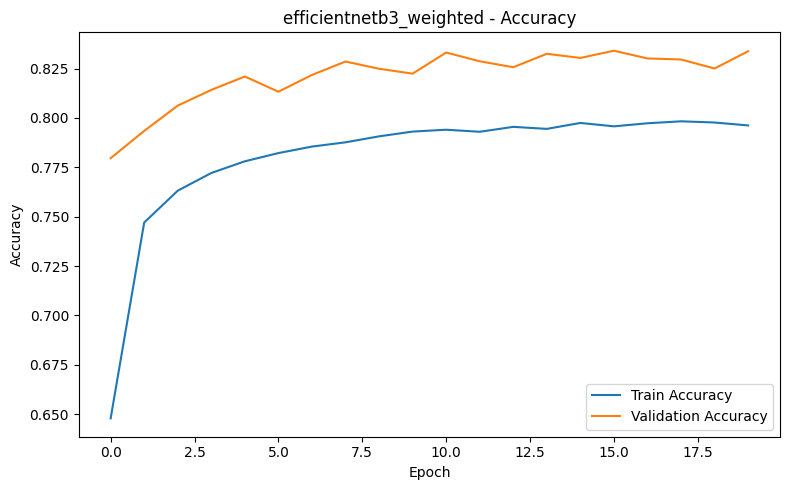

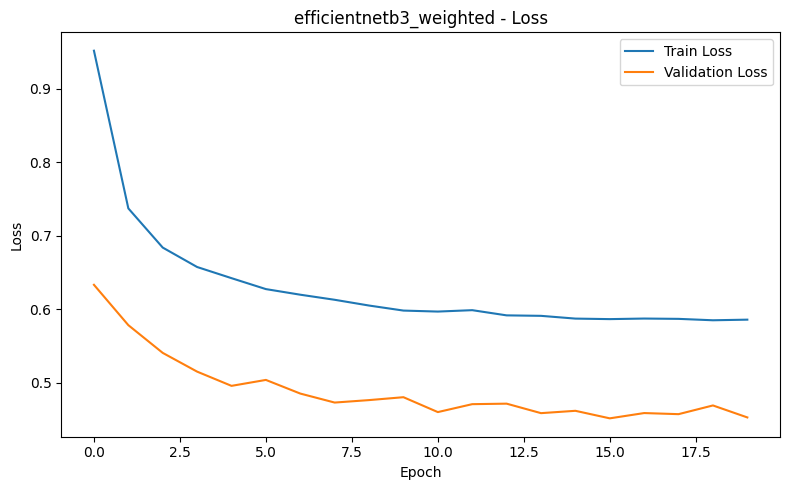

In [11]:
def plot_training_curves(history, model_name):
    plt.figure(figsize=(8, 5))
    plt.plot(history.history["accuracy"], label="Train Accuracy")
    plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
    plt.title(f"{model_name} - Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.tight_layout()
    plt.savefig(f"{model_name}_accuracy_curve.png", dpi=300)
    plt.show()

    plt.figure(figsize=(8, 5))
    plt.plot(history.history["loss"], label="Train Loss")
    plt.plot(history.history["val_loss"], label="Validation Loss")
    plt.title(f"{model_name} - Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.tight_layout()
    plt.savefig(f"{model_name}_loss_curve.png", dpi=300)
    plt.show()

plot_training_curves(history, "efficientnetb3_weighted")

In [12]:
y_true = []
y_pred = []

for images, labels in test_ds:
    preds = efficientnetb3_weighted_model.predict(images, verbose=0)
    y_true.extend(np.argmax(labels.numpy(), axis=1))
    y_pred.extend(np.argmax(preds, axis=1))

y_true = np.array(y_true)
y_pred = np.array(y_pred)

In [13]:
report = classification_report(
    y_true,
    y_pred,
    target_names=class_names,
    output_dict=True
)

df_report = pd.DataFrame(report).transpose()
df_report.to_csv("efficientnetb3_weighted_classification_report.csv")

df_report

,precision,recall,f1-score,support
CNV,0.946739,0.825592,0.882025,3165.000000
DME,0.764508,0.827116,0.794580,1099.000000
DRUSEN,0.483846,0.784163,0.598441,783.000000
NORMAL,0.933361,0.872373,0.901837,2617.000000
accuracy,0.837552,0.837552,0.837552,0.837552
macro avg,0.782113,0.827311,0.794221,7664.000000
weighted avg,0.868747,0.837552,0.847278,7664.000000


In [14]:
print(classification_report(y_true, y_pred, target_names=class_names))

              precision    recall  f1-score   support

         CNV       0.95      0.83      0.88      3165
         DME       0.76      0.83      0.79      1099
      DRUSEN       0.48      0.78      0.60       783
      NORMAL       0.93      0.87      0.90      2617

    accuracy                           0.84      7664
   macro avg       0.78      0.83      0.79      7664
weighted avg       0.87      0.84      0.85      7664



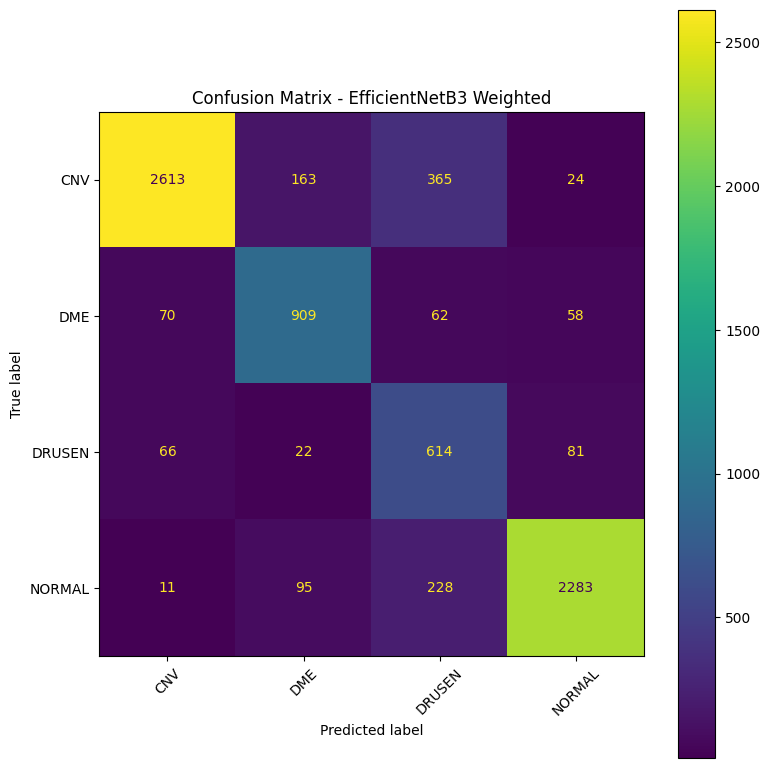

In [15]:
cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

fig, ax = plt.subplots(figsize=(8, 8))
disp.plot(ax=ax, values_format="d")
plt.title("Confusion Matrix - EfficientNetB3 Weighted")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("efficientnetb3_weighted_confusion_matrix.png", dpi=300)
plt.show()

In [16]:
metrics = {
    "model": "EfficientNetB3 Weighted",
    "accuracy": accuracy_score(y_true, y_pred),
    "precision_macro": precision_score(y_true, y_pred, average="macro"),
    "recall_macro": recall_score(y_true, y_pred, average="macro"),
    "f1_macro": f1_score(y_true, y_pred, average="macro"),
    "precision_weighted": precision_score(y_true, y_pred, average="weighted"),
    "recall_weighted": recall_score(y_true, y_pred, average="weighted"),
    "f1_weighted": f1_score(y_true, y_pred, average="weighted"),
    "training_time_seconds": training_time,
    "training_time_minutes": training_time / 60,
    "epochs_trained": len(history.history["loss"])
}

df_metrics = pd.DataFrame([metrics])
df_metrics.to_csv("efficientnetb3_weighted_metrics_summary.csv", index=False)

df_metrics

,model,accuracy,precision_macro,recall_macro,f1_macro,precision_weighted,recall_weighted,f1_weighted,training_time_seconds,training_time_minutes,epochs_trained
0,EfficientNetB3 Weighted,0.837552,0.782113,0.827311,0.794221,0.868747,0.837552,0.847278,5735.17223,95.586204,20


In [17]:
total_params = efficientnetb3_weighted_model.count_params()

trainable_params = np.sum([
    np.prod(v.shape) for v in efficientnetb3_weighted_model.trainable_weights
])

non_trainable_params = np.sum([
    np.prod(v.shape) for v in efficientnetb3_weighted_model.non_trainable_weights
])

params_summary = pd.DataFrame([{
    "model": "EfficientNetB3 Weighted",
    "total_params": total_params,
    "trainable_params": trainable_params,
    "non_trainable_params": non_trainable_params
}])

params_summary.to_csv("efficientnetb3_weighted_params_summary.csv", index=False)
params_summary

,model,total_params,trainable_params,non_trainable_params
0,EfficientNetB3 Weighted,10789683,6148,10783535.0
